
"MNIST ("Modified National Institute of Standards and Technology")  is a large, open source database of handwritten digits, most often used in image processing softwares. It is the de facto “hello world” dataset of computer vision. Since its release in 1999, this classic dataset of handwritten images has served as the basis for benchmarking classification algorithms. As new machine learning techniques emerge, MNIST remains a reliable resource for researchers and learners alike."



[Read more.](https://www.kaggle.com/c/digit-recognizer)


<a title="By Josef Steppan [CC BY-SA 4.0 (https://creativecommons.org/licenses/by-sa/4.0)], from Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:MnistExamples.png"><img width="512" alt="MnistExamples" src="https://upload.wikimedia.org/wikipedia/commons/2/27/MnistExamples.png"/></a>

**Step 1 — Knowing The Dataset**
As we have mentioned previously, the most important step in machine learning is understanding your dataset and going through it thoroughly.

Luckily, for us PyTorch provides an easy implementation to download the cleaned and already prepared data, using a few lines of code. Before starting, we need to make all the necessary installation and imports of the relevant libraries.



In [ ]:
!pip install torch torchvision

In [ ]:
#Import Libraries
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
from time import time
from torchvision import datasets, transforms
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

PyTorch has its own version of a numpy array called a **tensor**. All of the models and functions we apply on the data can only be done on tensor types meaning that our data will have to be converted into a tensor first.

**transforms.ToTensor()**: this function allows us to convert a numpy array into a tensor type.

Fortunately, Pytorch already contains several datasets that we can access.

In [ ]:
trainset = datasets.MNIST('train', download = True, train = True, transform = transforms.ToTensor())
testset = datasets.MNIST('test', download = True, train = False, transform = transforms.ToTensor())

# these datasets come from torchvision library with datasets

100%|██████████| 9912422/9912422 [00:00<00:00, 105121102.10it/s]


Extracting train/MNIST/raw/train-images-idx3-ubyte.gz to train/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 32589640.52it/s]

Extracting train/MNIST/raw/train-labels-idx1-ubyte.gz to train/MNIST/raw




100%|██████████| 1648877/1648877 [00:00<00:00, 25574818.97it/s]


...

Extracting test/MNIST/raw/train-labels-idx1-ubyte.gz to test/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 25945068.06it/s]


Extracting test/MNIST/raw/t10k-images-idx3-ubyte.gz to test/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 7404014.29it/s]

Extracting test/MNIST/raw/t10k-labels-idx1-ubyte.gz to test/MNIST/raw



So now we have a complete training and testing dataset! We can take a look at how large both of these datasets are:

In [ ]:
trainset

Dataset MNIST
    Number of datapoints: 60000
    Root location: train
    Split: Train
    StandardTransform
Transform: ToTensor()

In [ ]:
testset

Dataset MNIST
    Number of datapoints: 10000
    Root location: test
    Split: Test
    StandardTransform
Transform: ToTensor()

We can see that there are a large number of datapoints in the training and testing set. Training the model is a process that takes many iterations, and on each iteration the error is calculated and weights/bias are adjusted accordingly.

So we can split both the training and testing set into smaller groups of data called **batches**. PyTorch offers function that allows us to easily separate our datasets into batches called **DataLoader**.

In [ ]:
trainloader = DataLoader(trainset, batch_size = 32, shuffle = True)
testloader = DataLoader(testset, batch_size = 32, shuffle = True)

**Step 2 — Knowing The Dataset Better**

To obtain a single batch from our DataLoader, we can call a Python function called **iter()** which will allow us to access each batch by calling **.next()**

In [ ]:
for images, labels in trainloader:
  print(images, labels)
  break

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

In [ ]:
labels

tensor([6, 9, 3, 9, 2, 1, 5, 8, 9, 4, 7, 9, 0, 0, 2, 6, 2, 2, 2, 4])

Now let's see what the shapes of our images and labels are

In [ ]:
# ask what they think each number means
print(images.shape) # what the printed numbers/array mean: 10 (first number) represents our batch size, 1 (second number) represents the channels each image has, and 28 by 28 (third and fourth number) represents the length and width of each image.
print(labels.shape) #  what the printed numbers/array mean: 10(first number) represents the batch size

torch.Size([32, 1, 28, 28])
torch.Size([32])


Now let's plot and show what this image looks like:

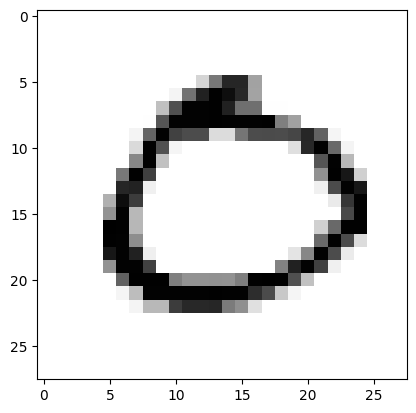

In [ ]:
plt.imshow(images[0].numpy().squeeze(), cmap = 'gray_r')
#actual image of image[0]

In [ ]:
labels[0] #label of image[0]

tensor(0)

Cool right! Let’s display some more images, this will give us a feel of how the dataset looks like.

This will generate a grid of images in a random order. Now, it is time to get started by defining the neural network we will be using.

**Step 3 — Creating the Model**

Now let's create our model! Each layer of a network will be a called in a separate variable. The main tools we will use are:
- **nn.Conv2d()**: applies a convolution for the given inputs
- **nn.Linear()**: applies a linear summation for the given inputs

In [ ]:
#testingéchecking to see that the layers match up
conv1 = nn.Conv2d(in_channels = 1, out_channels = 5, kernel_size = 3) #greyscale has a channel of 1, RGB has a channel of 3
conv2 = nn.Conv2d(in_channels = 5, out_channels = 3, kernel_size = 4, stride = 2)
pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2, padding=0) #pooling layer
#pool1 = nn.AdaptiveMaxPool2d((6,6)) #pooling layer
result = conv1(images)
print(result.shape) #tells us there is a batch of 20 and it returns 5 channels with a 26 by 26 shape
result = conv2(result)
print(result.shape) #tells us there is a batch of 20 and it returns 3 channels with a 12 by 12 shape
#convolution.shape = [batch, # of matrices/channels ,matrix size, matrix size]
result = pool1(result)
result.shape

#6

#https://dingyan89.medium.com/calculating-parameters-of-convolutional-and-fully-connected-layers-with-keras-186590df36c6#:~:text=Followed%20by%20a%20max%2Dpooling%20layer%2C%20the%20method%20of%20calculating,)%2F2%20%2B1%20%3D%2014.

torch.Size([32, 5, 26, 26])
torch.Size([32, 3, 12, 12])


torch.Size([32, 3, 6, 6])

In [ ]:
result.flatten(start_dim = 1).shape
#what does flatten do: result returns 3 matrices that are 12 by 12. flatten flattens the three 2D - matrices into a 1D matrix
#therefore [20 batches, 3*12*12 = 432]
#flattened convolution.shape = [batch, multiplied matrix sizes]

torch.Size([32, 108])

In [ ]:
result = result.flatten(start_dim = 1)
linear1 = nn.Linear(3 * 12 * 12, 10) #output = 10 because there are 10 possible numbers from 0 to 9

print(linear1(result))

Creating the layers is not enough to complete the network. We also have to set our activation functions as well as determine our output from the model. The main ones that we will use in this example are:
- **Rectified Linear Unit**
- **Softmax**

Now that we have all of the parts of our network we can combine everything together.

In [ ]:
for images, labels in trainloader:
  x = conv1(images)
  x = conv2(x)
  x = x.flatten(start_dim = 1)
  x = linear1(x)
  x = F.softmax(x, dim = 1)
  print(x.shape)

  break

torch.Size([20, 10])


A standard coding practice when it comes to making neural networks is by creating a new **class** to represent our model.

In [ ]:
class MyModel(nn.Module):
  def __init__(self):
    #fill out
    super(MyModel, self).__init__()
    self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 5, kernel_size = 3)
    #input is 1 28 by 28 matrix
    #output is 5 26 by 26 matrices - - based on convolution math/process/hyperparameters
    self.conv2 = nn.Conv2d(in_channels = 5, out_channels = 3, kernel_size = 4, stride = 2)
    #input is 5 26 by 26 matrices
    #output is 3 12 by 12 matrices  - based on convolution math/process/hyperparameters
    self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2, padding=0)
    #input is 3 12 by 12 matices
    #output is 3 6 by 6 matrices
    #self.linear1 = nn.Linear(3 * 6 * 6, 1000)
    self.linear1 = nn.LazyLinear(1000)
    #input is 3*12*12 = 432 because the convolutional layer before outputs/returns 3 12 by 12 matrices and passes it into linear 1
    # 432 is represented in the 1D shape. the (conv2) output's 1D shape will be [batch, 3*12*12 = 432]. The 1D shape is seen by typing
    self.linear2 = nn.Linear(1000, 500)
    self.linear3 = nn.Linear(500, 250)
    self.linear4 = nn.Linear(250, 125)
    self.linear5 = nn.Linear(125, 10)
    # output is 10 bc it will return 10 values, corresponding to the 10 possible numbers/outputs (from 0 to 9)
    #self.dropout = nn.Dropout(0.2) #dropout is only used during training not evaluation


  def forward(self, images):
    x = self.conv1(images)
    x = self.conv2(x)
    x = self.pool1(x)
    x = x.flatten(start_dim = 1)
    x = torch.relu(self.linear1(x))
    #x = self.dropout(x)
    x = torch.relu(self.linear2(x))
    #x = self.dropout(x)
    x = torch.relu(self.linear3(x))
    #x = self.dropout(x)
    x = torch.relu(self.linear4(x))
    #x = self.dropout(x)
    x = self.linear5(x) #will return 10 values, corresponding to the 10 possible numbers/outputs (from 0 to 9)
    #x = self.dropout(x)
    x = F.softmax(x, dim = 1) #will return 10 probabilties, corresponding to the probabilities of each number
    # when it comes to activation functions that return probabilities: Sigmoid is used for binary classification methods where we only have 2 classes, while SoftMax applies to multiclass problems
    return x


In [ ]:
## set hyperparameters, create model instance, loss function and optimizer
model = MyModel()
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)
#ADAM is what we usually use as an optimizer instead of SGD

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


In [ ]:
images.shape

torch.Size([32, 1, 28, 28])

In [ ]:
epochs = 10
all_train_loss = []
average_epoch_loss = []
y_pred_compare = []
y_pred_list = []
y_true_list = []

for epoch in range(epochs):
  print('EPOCH')
  epoch_loss = []
  for images, labels in trainloader:
    ##forward propogation##
    y_hat = model(images) #returns an array/tensor of ten probabilites. one for each possible number from 0 to 9.

    y_pred = torch.argmax(y_hat, dim = 1) #returns the index of the largest element in y_hat

    y_pred_compare = list(zip(y_pred.tolist(), labels.tolist()))

    y_pred_list.append(y_pred.tolist())
    y_true_list.append(labels.tolist())

    loss = loss_function(y_hat, labels)

    ##backward propogation##
    loss.backward() #calculating gradient
    optimizer.step() #taking the step, changing weights and so on according to gradient
    optimizer.zero_grad()#resetting gradient and step for the next iteration. sets to zero to be recalulated next turn.


    epoch_loss.append(loss.detach().item())
    all_train_loss.append(loss.detach().item())


  #print("Average Cross Entropy Loss" + str( sum(epoch_loss)/len(epoch_loss))))

  average_epoch_loss.append(sum(epoch_loss)/len(epoch_loss))



EPOCH
EPOCH
EPOCH
EPOCH
EPOCH
EPOCH
EPOCH
EPOCH
EPOCH
EPOCH


In [ ]:
#turning y_true and y_pred lists into one long list instead of a list of bacthes(lists)
#unnesting the lists
y_true_list = sum(y_true_list, [])

y_pred_list = sum(y_pred_list, [])

print(y_pred_list)
print(y_true_list)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



Let's take a quick look at what the output from this looks like:

In [ ]:
print(average_epoch_loss)

[1.7738542067845662, 1.5533775293986003, 1.5252953109105427, 1.5124642864863078, 1.5052765292485555, 1.5002588189442954, 1.4963479211807251, 1.4926510702768963, 1.4911309466044107, 1.4883030990600585]


In [ ]:
print(all_train_loss)

[2.301555633544922, 2.302492141723633, 2.3032960891723633, 2.3027985095977783, 2.3025400638580322, 2.303046703338623, 2.3032565116882324, 2.3015458583831787, 2.3007991313934326, 2.302154064178467, 2.302963972091675, 2.30178165435791, 2.303152084350586, 2.3012704849243164, 2.301403045654297, 2.301842212677002, 2.3009841442108154, 2.302861213684082, 2.3016645908355713, 2.3022289276123047, 2.3020405769348145, 2.3026466369628906, 2.301642656326294, 2.3022477626800537, 2.301881790161133, 2.301501750946045, 2.3004660606384277, 2.3017876148223877, 2.300631046295166, 2.3021857738494873, 2.300290584564209, 2.301199197769165, 2.3009982109069824, 2.3012290000915527, 2.30063796043396, 2.2997019290924072, 2.2989914417266846, 2.2993953227996826, 2.3009440898895264, 2.3002161979675293, 2.2998673915863037, 2.3007564544677734, 2.2989940643310547, 2.2998478412628174, 2.3004746437072754, 2.298157215118408, 2.2975103855133057, 2.2987442016601562, 2.2985169887542725, 2.2985832691192627, 2.297259569168091, 

In [ ]:
print(y_pred_compare)


[(8, 8), (8, 8), (3, 3), (9, 9), (3, 3), (4, 4), (7, 7), (9, 9), (2, 2), (0, 0), (6, 6), (3, 3), (4, 4), (1, 1), (7, 7), (1, 1), (0, 0), (5, 6), (6, 6), (1, 1), (5, 5), (7, 7), (0, 0), (5, 5), (8, 8), (2, 2), (8, 8), (0, 0), (2, 2), (1, 1), (5, 5), (7, 7)]


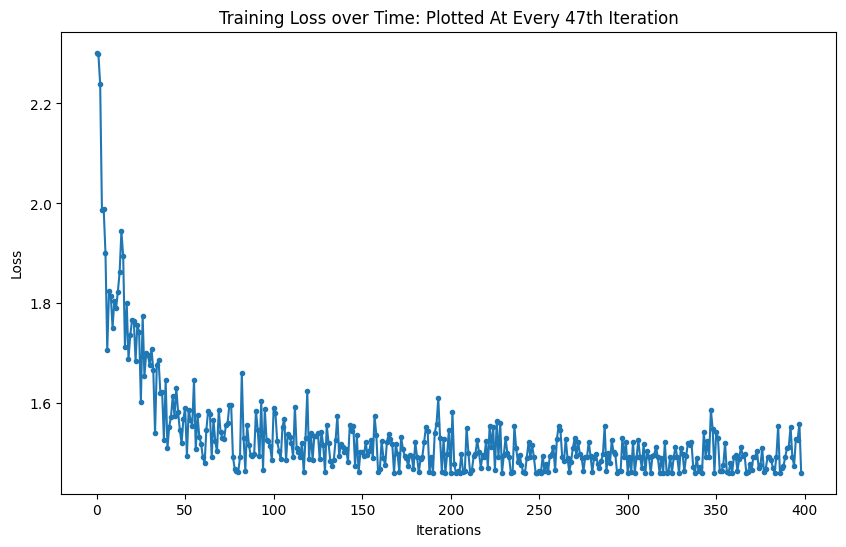

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

n = 47 # Plot every 47th element
ax.plot(all_train_loss[::n], marker='o', markersize=3)
ax.set_xlabel('Iterations')
ax.set_ylabel('Loss')
ax.set_title('Training Loss over Time: Plotted At Every 47th Iteration')

plt.show()
#plotting without including every single datapoint to avoid overcrowding #excluding datapoints are regular intervals

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
model_path = "/content/drive/MyDrive/UofT Computer Vision"
print("data_path:", model_path)
files = os.listdir(model_path)  # Get all the files in that directory
print(f"Files in current directory '{model_path}': {files}")

data_path: /content/drive/MyDrive/UofT Computer Vision
Files in current directory '/content/drive/MyDrive/UofT Computer Vision': ['Intro_To_Python_Student (1).ipynb', 'Advanced_Python_Student (1).ipynb', 'Neural_Networks_student (1).ipynb', 'airbnb_nyc_cleaned.xlsx', 'airbnb_nyc_cleaned2.csv', 'Data_Cleaning_VIsualization_student.ipynb', 'Machine Learning .pptx', 'Neural Networks.pptx', 'AirBNB_NN_Exercise_student.ipynb', 'number_predict6.pth', 'AirBNB_NN_Exercise_instructor.ipynb', 'number_predict7.pth', 'number_predict9.pth', 'saved model architecture and report.gdoc', 'number_predict8.pth', 'MNIST_GRADIO.ipynb', 'MNIST_Project_student.ipynb', 'number_predict10.pth', 'model10 report.gdoc', 'number_predict10_1.pkl', 'MNIST_GRADIO2.ipynb']


In [ ]:
#saving model

model_name = 'number_predict11.pth'

PATH = model_path + "/" + model_name

torch.save(model.state_dict(), PATH)
print(f"Saved model: {model_name}")

Saved model: number_predict11.pth


In [ ]:
#loading model
import torch
import torch.nn as nn
model_path = "/content/drive/MyDrive/UofT Computer Vision"
model_name = 'number_predict11.pth'
PATH = model_path + "/" + model_name
model = MyModel()
model.load_state_dict(torch.load(PATH)) #loading named model from drive
model.eval() #lets model know that its evaluating and so turns off dropout

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


MyModel(
  (conv1): Conv2d(1, 5, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(5, 3, kernel_size=(4, 4), stride=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear1): LazyLinear(in_features=0, out_features=1000, bias=True)
  (linear2): Linear(in_features=1000, out_features=500, bias=True)
  (linear3): Linear(in_features=500, out_features=250, bias=True)
  (linear4): Linear(in_features=250, out_features=125, bias=True)
  (linear5): Linear(in_features=125, out_features=10, bias=True)
)

In [ ]:
Y_TRUE = []
Y_PRED = []

for images, labels in testloader:
  y_hat = model(images)
  y_pred = torch.argmax(y_hat, dim = 1)
  print(type(y_pred))
  print(y_pred.tolist())
  print(labels.tolist())
  print('\n')
  Y_TRUE.append(labels.tolist())
  Y_PRED.append(y_pred.tolist())


<class 'torch.Tensor'>
[8, 4, 8, 9, 4, 3, 1, 2, 8, 2, 0, 9, 1, 2, 8, 1, 5, 0, 1, 9, 0, 7, 5, 7, 3, 5, 9, 7, 9, 2, 3, 4]
[8, 4, 8, 9, 4, 3, 1, 2, 8, 2, 0, 9, 1, 2, 8, 1, 5, 0, 1, 9, 0, 7, 5, 7, 3, 5, 4, 7, 9, 2, 3, 4]


<class 'torch.Tensor'>
[8, 3, 9, 7, 4, 6, 7, 6, 9, 0, 9, 0, 9, 6, 7, 0, 9, 8, 5, 8, 2, 2, 8, 3, 9, 0, 3, 8, 5, 8, 6, 5]
[8, 3, 9, 7, 4, 6, 7, 6, 9, 0, 9, 0, 9, 6, 7, 0, 9, 8, 5, 8, 2, 2, 8, 3, 9, 9, 3, 8, 5, 8, 6, 5]


<class 'torch.Tensor'>
[7, 6, 4, 2, 4, 7, 7, 7, 3, 6, 0, 1, 1, 3, 4, 7, 0, 7, 6, 3, 0, 7, 1, 4, 5, 1, 7, 5, 5, 7, 2, 1]
[7, 6, 4, 2, 4, 7, 7, 7, 3, 6, 0, 1, 1, 3, 4, 7, 0, 7, 6, 3, 0, 7, 1, 4, 5, 1, 7, 5, 5, 7, 2, 1]


<class 'torch.Tensor'>
[1, 7, 8, 7, 8, 2, 2, 3, 6, 0, 5, 2, 1, 0, 4, 5, 5, 7, 2, 0, 1, 7, 9, 3, 9, 0, 6, 7, 4, 0, 1, 9]
[1, 7, 8, 7, 8, 2, 2, 3, 6, 0, 8, 2, 1, 0, 4, 5, 5, 7, 2, 0, 1, 7, 9, 3, 9, 0, 6, 7, 4, 6, 1, 9]


<class 'torch.Tensor'>
[3, 0, 5, 2, 7, 3, 3, 1, 1, 1, 7, 4, 4, 3, 7, 3, 0, 2, 3, 9, 5, 3, 1, 1, 4, 3, 7, 8, 7, 8, 2, 8]
[3, 

In [ ]:
Y_TRUE = sum(Y_TRUE, [])

Y_PRED = sum(Y_PRED, [])

print(Y_PRED)
print(Y_TRUE)

#unnesting the list


[8, 4, 8, 9, 4, 3, 1, 2, 8, 2, 0, 9, 1, 2, 8, 1, 5, 0, 1, 9, 0, 7, 5, 7, 3, 5, 9, 7, 9, 2, 3, 4, 8, 3, 9, 7, 4, 6, 7, 6, 9, 0, 9, 0, 9, 6, 7, 0, 9, 8, 5, 8, 2, 2, 8, 3, 9, 0, 3, 8, 5, 8, 6, 5, 7, 6, 4, 2, 4, 7, 7, 7, 3, 6, 0, 1, 1, 3, 4, 7, 0, 7, 6, 3, 0, 7, 1, 4, 5, 1, 7, 5, 5, 7, 2, 1, 1, 7, 8, 7, 8, 2, 2, 3, 6, 0, 5, 2, 1, 0, 4, 5, 5, 7, 2, 0, 1, 7, 9, 3, 9, 0, 6, 7, 4, 0, 1, 9, 3, 0, 5, 2, 7, 3, 3, 1, 1, 1, 7, 4, 4, 3, 7, 3, 0, 2, 3, 9, 5, 3, 1, 1, 4, 3, 7, 8, 7, 8, 2, 8, 8, 6, 1, 3, 3, 1, 8, 3, 5, 1, 8, 1, 8, 8, 7, 2, 0, 4, 1, 2, 5, 7, 3, 4, 3, 6, 1, 3, 3, 1, 1, 3, 6, 7, 1, 6, 6, 8, 1, 4, 9, 8, 4, 1, 9, 7, 6, 7, 6, 4, 1, 7, 4, 3, 9, 4, 6, 0, 2, 5, 7, 5, 1, 0, 6, 5, 7, 2, 5, 5, 0, 7, 6, 3, 8, 7, 8, 2, 2, 1, 1, 4, 1, 2, 4, 6, 7, 3, 3, 5, 5, 4, 5, 4, 9, 0, 8, 9, 7, 9, 2, 7, 3, 2, 1, 6, 2, 6, 6, 0, 5, 7, 3, 2, 3, 9, 0, 3, 8, 5, 3, 4, 1, 5, 8, 8, 0, 0, 9, 8, 2, 5, 2, 1, 0, 1, 9, 3, 3, 1, 9, 4, 8, 5, 1, 5, 3, 5, 8, 0, 3, 6, 1, 0, 4, 5, 5, 1, 3, 5, 9, 7, 1, 8, 9, 8, 9, 7, 8, 7, 5, 5, 2, 

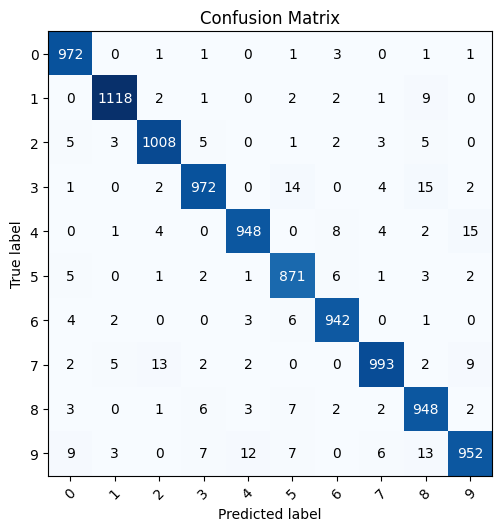

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_TRUE, Y_PRED, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(cm, cmap=plt.cm.Blues)

class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print('\nAccuracy: {:.2f}\n'.format(accuracy_score(Y_TRUE, Y_PRED)))

print('Micro Precision: {:.2f}'.format(precision_score(Y_TRUE, Y_PRED, average='micro')))
print('Micro Recall: {:.2f}'.format(recall_score(Y_TRUE, Y_PRED, average='micro')))
print('Micro F1-score: {:.2f}\n'.format(f1_score(Y_TRUE, Y_PRED, average='micro')))

print('Macro Precision: {:.2f}'.format(precision_score(Y_TRUE, Y_PRED, average='macro')))
print('Macro Recall: {:.2f}'.format(recall_score(Y_TRUE, Y_PRED, average='macro')))
print('Macro F1-score: {:.2f}\n'.format(f1_score(Y_TRUE, Y_PRED, average='macro')))

print('Weighted Precision: {:.2f}'.format(precision_score(Y_TRUE, Y_PRED, average='weighted')))
print('Weighted Recall: {:.2f}'.format(recall_score(Y_TRUE, Y_PRED, average='weighted')))
print('Weighted F1-score: {:.2f}'.format(f1_score(Y_TRUE, Y_PRED, average='weighted')))

from sklearn.metrics import classification_report
print('\nClassification Report\n')
print(classification_report(Y_TRUE, Y_PRED, target_names=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']))


#https://towardsdatascience.com/confusion-matrix-for-your-multi-class-machine-learning-model-ff9aa3bf7826

#Support is the number of actual occurrences of the class in the specified dataset. Imbalanced support in the training data may indicate structural weaknesses in the reported scores of the classifier and could indicate the need for stratified sampling or rebalancing.



Accuracy: 0.97

Micro Precision: 0.97
Micro Recall: 0.97
Micro F1-score: 0.97

Macro Precision: 0.97
Macro Recall: 0.97
Macro F1-score: 0.97

Weighted Precision: 0.97
Weighted Recall: 0.97
Weighted F1-score: 0.97

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.96      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.96      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.95      0.97      0.96       974
           9       0.97      0.94      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [ ]:
import pickle

model_name = "number_predict11_1"
with open("/content/drive/MyDrive/UofT Computer Vision" + "/" + model_name +'.pkl', 'wb') as f:
    pickle.dump(model, f)

Since we used the softmax function which returns the probabilities, we can take the maximum probability from each row in our output and use that as the predicted number that our model returns for a specific image.

In [ ]:
y = model(testloader[])

tensor([7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 9, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7])
tensor([6, 6, 0, 4, 3, 1, 0, 5, 3, 9, 1, 3, 0, 6, 6, 3, 1, 6, 0, 5, 5, 4, 8, 4,
        8, 4, 5, 6, 3, 4, 3, 2, 5, 4, 3, 3, 9, 2, 1, 4, 0, 8, 9, 7, 8, 4, 5, 8,
        6, 2, 6, 0, 5, 9, 6, 1, 6, 6, 9, 7, 4, 9, 1, 7])


NameError: ignored

In [ ]:
labels

So now we have our neural network model created, we have to give it a way of learning. To do this we have to several more things:
- **Loss Function**
- **Optimizer**
- **Hyperparameters**

In [ ]:
def get_accuracy(output, labels, batch_size):
  diff = output - labels
  wrong_labels = np.count_nonzero(diff)
  accuracy = (batch_size - wrong_labels)/batch_size * 100
  print('Accuracy is: ', accuracy, '%')
  return None


def get_correct(output, labels, batch_size):
  diff = output - labels
  wrong_labels = np.count_nonzero(diff)
  return batch_size - wrong_labels


Now let's put everything together and let our neural network learn!

**EXCERCISE 1**
Test your model on the testing set and obtain the accuracy!

In [ ]:
class MyModel(nn.Module):
  def __init__(self):
    #fill out
    super(MyModel, self).__init__()
    self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 5, kernel_size = 3)
    #input is 1 28 by 28 matrix
    #output is 5 26 by 26 matrices - - based on convolution math/process/hyperparameters
    self.conv2 = nn.Conv2d(in_channels = 5, out_channels = 3, kernel_size = 4, stride = 2)
    #input is 5 26 by 26 matrices
    #output is 3 12 by 12 matrices  - based on convolution math/process/hyperparameters
    self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2, padding=0)
    #input is 3 12 by 12 matices
    #output is 3 6 by 6 matrices
    self.linear1 = nn.Linear(3 * 6 * 6, 1000)
    #input is 3*12*12 = 432 because the convolutional layer before outputs/returns 3 12 by 12 matrices and passes it into linear 1
    # 432 is represented in the 1D shape. the (conv2) output's 1D shape will be [batch, 3*12*12 = 432]. The 1D shape is seen by typing
    self.linear2 = nn.Linear(1000, 500)
    self.linear3 = nn.Linear(500, 250)
    self.linear4 = nn.Linear(250, 125)
    self.linear5 = nn.Linear(125, 10)
    # output is 10 bc it will return 10 values, corresponding to the 10 possible numbers/outputs (from 0 to 9)
    self.dropout = nn.Dropout(0.2) #dropout is only used during training not evaluation

  def forward(self, images):
    x = self.conv1(images)
    x = self.conv2(x)
    x = self.pool1(x)
    x = x.flatten(start_dim = 1)
    x = self.linear1(x)
    x = self.dropout(x)
    x = self.linear2(x)
    x = self.dropout(x)
    x = self.linear3(x)
    x = self.dropout(x)
    x = self.linear4(x)
    x = self.dropout(x)
    x = self.linear5(x) #will return 10 values, corresponding to the 10 possible numbers/outputs (from 0 to 9)
    x = self.dropout(x)
    x = F.softmax(x, dim = 1) #will return 10 probabilties, corresponding to the probabilities of each number
    return x

  def get_accuracy(output, labels, batch_size):
    diff = output - labels
    wrong_labels = np.count_nonzero(diff)
    accuracy = (batch_size - wrong_labels)/batch_size * 100
    print('Accuracy is: ', accuracy, '%')
    return None


  def get_correct(output, labels, batch_size):
    diff = output - labels
    wrong_labels = np.count_nonzero(diff)
    return batch_size - wrong_labels

Congratulations, you just made your first image classification neural network :)
The next step is to tune the hyperparameters and play around with the overall network to find the combination that will give the best model.